In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Loading Data Set

In [2]:
df = pd.read_csv("Raw_Ecommerce_Sales_Data.csv")

In [5]:
df

,Order_ID,Order_Date,Customer,Product,Category,Region,Quantity,Unit_Price,Discount,Revenue
0,ORD10001,2025-07-25 00:00:00,Customer_095,Headphones,Accessories,West,5.0,10349.15,0.05,49158.46
1,ORD10002,2025-04-09 00:00:00,Customer_012,Monitor,Electronics,North,2.0,22268.58,0.05,42310.30
2,ORD10003,2025-05-24 00:00:00,Customer_057,Power Bank,Accessories,Central,2.0,1559.46,0.15,2651.08
3,ORD10004,2025-05-02 00:00:00,Customer_005,Speaker,Audio,East,4.0,9781.11,0.20,31299.55
4,ORD10005,2025-03-17 00:00:00,Customer_009,USB Hub,Accessories,South,4.0,1201.83,0.00,4807.32
...,...,...,...,...,...,...,...,...,...,...
748,ORD10749,2025-06-22 00:00:00,Customer_046,Monitor,Electronics,West,5.0,11839.56,0.10,53278.02
749,ORD10750,2025-03-26 00:00:00,Customer_025,External SSD,Storage,North,3.0,12433.26,0.05,35434.79
750,ORD10301,2025-06-14 00:00:00,Customer_058,USB Hub,Accessories,Central,3.0,2075.43,0.10,5603.66
751,ORD10451,2025-04-01 00:00:00,Customer_090,Smartwatch,Wearables,North,1.0,3005.58,0.00,3005.58


In [ ]:
# Data Inspection 

In [6]:
df.shape

(753, 10)

In [7]:
df.head()

,Order_ID,Order_Date,Customer,Product,Category,Region,Quantity,Unit_Price,Discount,Revenue
0,ORD10001,2025-07-25 00:00:00,Customer_095,Headphones,Accessories,West,5.0,10349.15,0.05,49158.46
1,ORD10002,2025-04-09 00:00:00,Customer_012,Monitor,Electronics,North,2.0,22268.58,0.05,42310.30
2,ORD10003,2025-05-24 00:00:00,Customer_057,Power Bank,Accessories,Central,2.0,1559.46,0.15,2651.08
3,ORD10004,2025-05-02 00:00:00,Customer_005,Speaker,Audio,East,4.0,9781.11,0.20,31299.55
4,ORD10005,2025-03-17 00:00:00,Customer_009,USB Hub,Accessories,South,4.0,1201.83,0.00,4807.32


In [8]:
df.tail()

,Order_ID,Order_Date,Customer,Product,Category,Region,Quantity,Unit_Price,Discount,Revenue
748,ORD10749,2025-06-22 00:00:00,Customer_046,Monitor,Electronics,West,5.0,11839.56,0.10,53278.02
749,ORD10750,2025-03-26 00:00:00,Customer_025,External SSD,Storage,North,3.0,12433.26,0.05,35434.79
750,ORD10301,2025-06-14 00:00:00,Customer_058,USB Hub,Accessories,Central,3.0,2075.43,0.10,5603.66
751,ORD10451,2025-04-01 00:00:00,Customer_090,Smartwatch,Wearables,North,1.0,3005.58,0.00,3005.58
752,ORD10601,2025-01-01 00:00:00,Customer_044,Speaker,Audio,East,1.0,8750.35,0.15,7437.80


In [9]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer', 'Product', 'Category', 'Region',
       'Quantity', 'Unit_Price', 'Discount', 'Revenue'],
      dtype='str')

In [10]:
df.dtypes

Order_ID          str
Order_Date        str
Customer          str
Product           str
Category          str
Region            str
Quantity      float64
Unit_Price    float64
Discount      float64
Revenue       float64
dtype: object

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_ID    753 non-null    str    
 1   Order_Date  753 non-null    str    
 2   Customer    752 non-null    str    
 3   Product     753 non-null    str    
 4   Category    753 non-null    str    
 5   Region      753 non-null    str    
 6   Quantity    752 non-null    float64
 7   Unit_Price  752 non-null    float64
 8   Discount    752 non-null    float64
 9   Revenue     752 non-null    float64
dtypes: float64(4), str(6)
memory usage: 104.9 KB


In [12]:
df.describe()

,Quantity,Unit_Price,Discount,Revenue
count,752.000000,752.000000,752.000000,752.000000
mean,2.147606,16220.975864,0.076330,32046.084561
std,1.216079,19734.608694,0.057681,47913.052731
min,1.000000,541.870000,0.000000,776.490000
25%,1.000000,3170.235000,0.050000,5371.082500
50%,2.000000,8226.750000,0.100000,13877.845000
75%,3.000000,19209.527500,0.100000,38328.350000
max,5.000000,89766.870000,0.200000,420178.440000


In [13]:
# Identifying Missing values

In [14]:
df.isnull().sum()

Order_ID      0
Order_Date    0
Customer      1
Product       0
Category      0
Region        0
Quantity      1
Unit_Price    1
Discount      1
Revenue       1
dtype: int64

In [15]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

Order_ID      0.000000
Order_Date    0.000000
Customer      0.132802
Product       0.000000
Category      0.000000
Region        0.000000
Quantity      0.132802
Unit_Price    0.132802
Discount      0.132802
Revenue       0.132802
dtype: float64

In [ ]:
# Handling Missing values

In [42]:
df["Customer"] = df["Customer"].fillna("Unknown")

In [44]:
df["Customer"].isnull().sum()

np.int64(0)

In [45]:
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())

In [46]:
df["Quantity"].isnull().sum()

np.int64(0)

In [50]:
df["Unit_Price"] = df["Unit_Price"].fillna(df["Unit_Price"].median())

In [52]:
df["Unit_Price"].isnull().sum()

np.int64(0)

In [48]:
df["Discount"] = df["Discount"].fillna(0)

In [49]:
df["Discount"].isnull().sum()

np.int64(0)

In [ ]:
# Identifying Duplicate records

In [16]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
748    False
749    False
750     True
751     True
752     True
Length: 753, dtype: bool

In [17]:
df.duplicated().sum()

np.int64(3)

In [18]:
df[df.duplicated()]

,Order_ID,Order_Date,Customer,Product,Category,Region,Quantity,Unit_Price,Discount,Revenue
750,ORD10301,2025-06-14 00:00:00,Customer_058,USB Hub,Accessories,Central,3.0,2075.43,0.10,5603.66
751,ORD10451,2025-04-01 00:00:00,Customer_090,Smartwatch,Wearables,North,1.0,3005.58,0.00,3005.58
752,ORD10601,2025-01-01 00:00:00,Customer_044,Speaker,Audio,East,1.0,8750.35,0.15,7437.80


In [ ]:
# Removing Duplicates

In [19]:
df = df.drop_duplicates()

In [21]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Cleaning categorical columns

In [31]:
df["Customer"] = df["Customer"].str.strip().str.title()

df["Product"] = df["Product"].str.strip().str.title()

df["Category"] = df["Category"].str.strip().str.title()

df["Region"] = df["Region"].str.strip().str.title()

In [34]:
df[["Customer","Product","Region","Category",]]

,Customer,Product,Region,Category
0,Customer_095,Headphones,West,Accessories
1,Customer_012,Monitor,North,Electronics
2,Customer_057,Power Bank,Central,Accessories
3,Customer_005,Speaker,East,Audio
4,Customer_009,Usb Hub,South,Accessories
...,...,...,...,...
745,Customer_033,Usb Hub,East,Accessories
746,Customer_026,Tablet,East,Electronics
747,Customer_087,Laptop,West,Electronics
748,Customer_046,Monitor,West,Electronics


In [ ]:
# Correcting data types

In [37]:
df["Order_Date"]=pd.to_datetime(df["Order_Date"],errors="coerce")

In [41]:
df.dtypes

Order_ID                 str
Order_Date    datetime64[us]
Customer                 str
Product                  str
Category                 str
Region                   str
Quantity             float64
Unit_Price           float64
Discount             float64
Revenue              float64
dtype: object

In [ ]:
# Creating Calculated Columns

In [54]:
df["Gross_Sales"] = df["Quantity"] * df["Unit_Price"]

In [58]:
df["Gross_Sales"] 

0      51745.75
1      44537.16
2       3118.92
3      39124.44
4       4807.32
         ...   
745     1961.74
746    28486.24
747    63711.84
748    59197.80
749    37299.78
Name: Gross_Sales, Length: 750, dtype: float64

In [56]:
df["Discount_Amount"] = (df["Gross_Sales"] * df["Discount"])

In [57]:
df["Discount_Amount"]

0      2587.2875
1      2226.8580
2       467.8380
3      7824.8880
4         0.0000
         ...    
745      98.0870
746       0.0000
747    6371.1840
748    5919.7800
749    1864.9890
Name: Discount_Amount, Length: 750, dtype: float64

In [59]:
df["Calculated_Revenue"] = (df["Gross_Sales"] - df["Discount_Amount"])

In [60]:
df["Calculated_Revenue"]

0      49158.4625
1      42310.3020
2       2651.0820
3      31299.5520
4       4807.3200
          ...    
745     1863.6530
746    28486.2400
747    57340.6560
748    53278.0200
749    35434.7910
Name: Calculated_Revenue, Length: 750, dtype: float64

In [61]:
df["Revenue"] = df["Calculated_Revenue"]
df.drop(columns=["Calculated_Revenue"], inplace=True)

In [63]:
df["Revenue"]

0      49158.4625
1      42310.3020
2       2651.0820
3      31299.5520
4       4807.3200
          ...    
745     1863.6530
746    28486.2400
747    57340.6560
748    53278.0200
749    35434.7910
Name: Revenue, Length: 750, dtype: float64

In [ ]:
# Calculating KPIs

In [ ]:
# Total Revenue

In [66]:
Total_Revenue = df["Revenue"].sum()
print(Total_Revenue)

24014840.2885


In [70]:
Total_Orders = df["Order_ID"].count()
print(Total_Orders)

750


In [71]:
Total_Quantity = df["Quantity"].sum()
print(Total_Quantity)

1612.0


In [74]:
Average_Order_Value = Total_Revenue/Total_Orders
print(Average_Order_Value)

32019.787051333333


In [76]:
Average_Revenue = df["Revenue"].mean()
print(Average_Revenue)

32019.787051333333


In [ ]:
# Analysis

In [107]:
category_sales = (df.groupby("Category")["Revenue"].sum())
print(category_sales.max())

16843075.465


In [109]:
region_sales = (df.groupby("Region")["Revenue"].sum())
print(region_sales.max())

5711969.519


In [111]:
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)
monthly_sales = (df.groupby("Month")["Revenue"].sum())
print(monthly_sales)

Month
2025-01    2.269405e+06
2025-02    1.978658e+06
2025-03    3.459460e+06
2025-04    2.376750e+06
2025-05    2.484271e+06
2025-06    2.767144e+06
2025-07    2.696760e+06
2025-08    3.538524e+06
2025-09    2.442317e+06
Name: Revenue, dtype: float64


In [114]:
top_10_products = (df.groupby("Product")["Revenue"].sum().head(10))
print(top_10_products)

Product
External Ssd           1.581093e+06
Gaming Mouse           2.260398e+05
Headphones             6.307497e+05
Keyboard               2.024595e+05
Laptop                 8.203867e+06
Mechanical Keyboard    7.238168e+05
Monitor                1.824004e+06
Power Bank             2.194334e+05
Printer                1.562039e+06
Smartphone             3.813861e+06
Name: Revenue, dtype: float64


In [121]:
top_10_customers = (df.groupby("Customer")["Revenue"].sum())
print(top_10_customers)

Customer
Customer_001    190583.1080
Customer_002    292658.9270
Customer_003    121392.1745
Customer_004    139330.9890
Customer_005    234234.0020
                   ...     
Customer_098    173125.6735
Customer_099    142735.7705
Customer_100    196652.7875
Customer_999      2218.1220
Unknown          27716.0200
Name: Revenue, Length: 102, dtype: float64


In [117]:
low_performing_products = (df.groupby("Product")["Revenue"].sum().sort_values(ascending=True).head(10))
print(low_performing_products.idxmax())

Printer


In [97]:
Q1 = df["Revenue"].quantile(0.25)
Q3 = df["Revenue"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[(df["Revenue"] < lower_bound)|(df["Revenue"] > upper_bound)]

print("Number of Revenue Outliers:", len(outliers))

Number of Revenue Outliers: 68


In [99]:
import os

os.makedirs("Day_19_Charts", exist_ok=True)

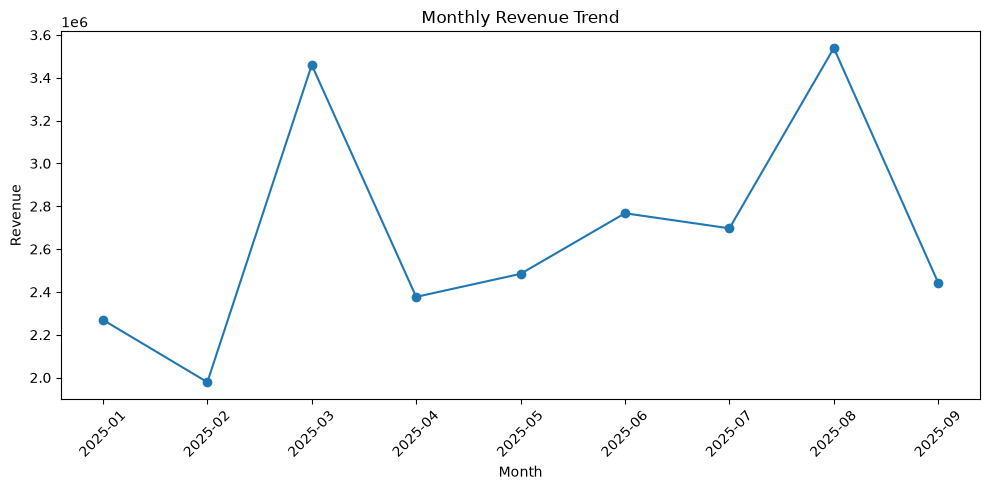

In [100]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "Day_19_Charts/Monthly_Revenue_Trend.png",
    dpi=300
)

plt.show()

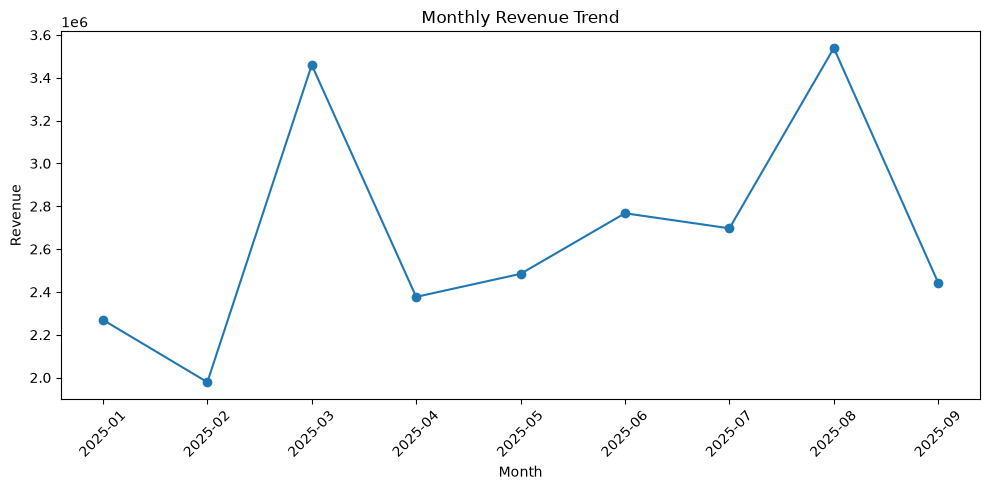

In [101]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "Day_19_Charts/Monthly_Revenue_Trend.png",
    dpi=300
)

plt.show()

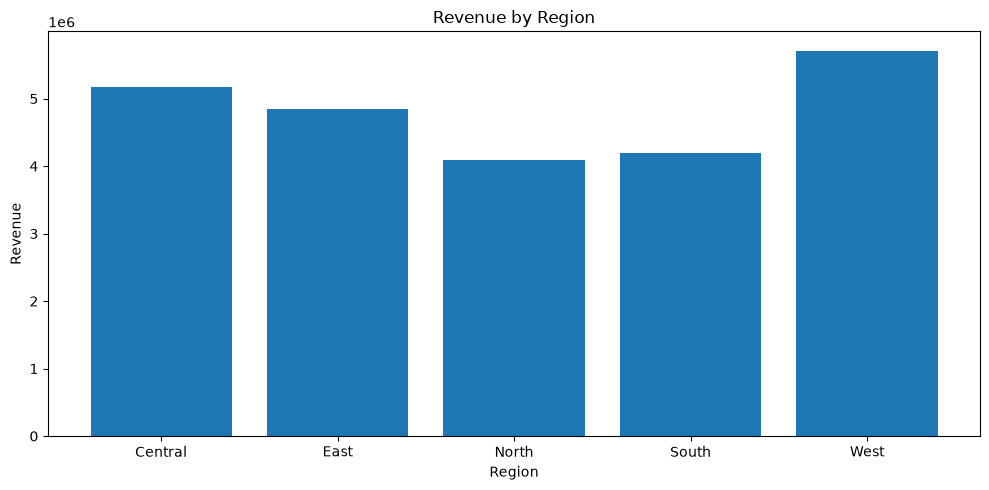

In [102]:
plt.figure(figsize=(10, 5))

plt.bar(
    region_sales.index,
    region_sales.values
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    "Day_19_Charts/Revenue_by_Region.png",
    dpi=300
)

plt.show()

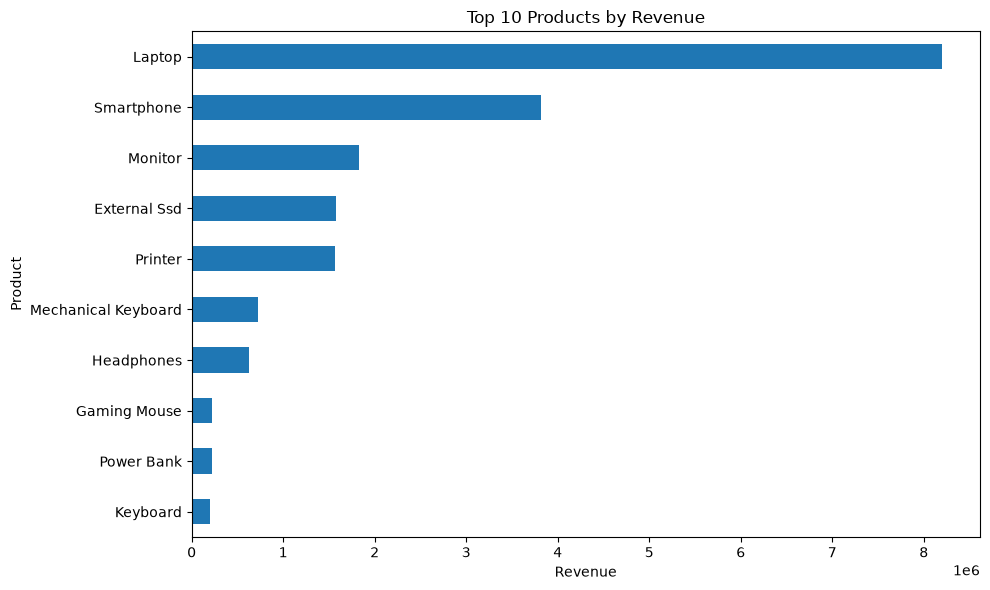

In [103]:
plt.figure(figsize=(10, 6))

top_10_products.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "Day_19_Charts/Top_10_Products.png",
    dpi=300
)

plt.show()

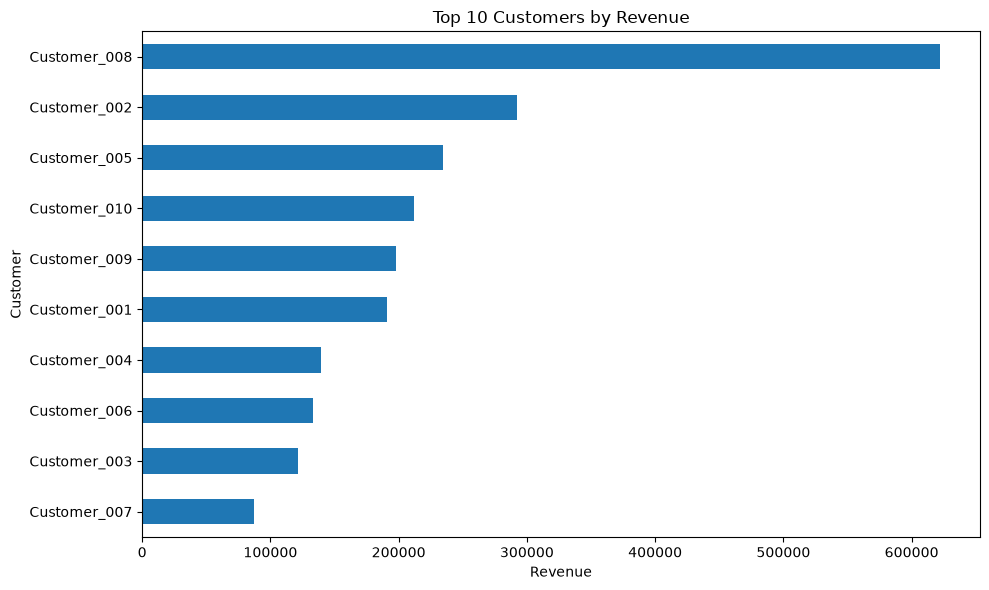

In [104]:
plt.figure(figsize=(10, 6))

top_10_customers.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer")

plt.tight_layout()

plt.savefig(
    "Day_19_Charts/Top_10_Customers.png",
    dpi=300
)

plt.show()

In [105]:
df.to_csv("Day_19_Cleaned_Data.csv",index=False)